In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree

/Users/art/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
iris = load_iris()

In [3]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df["target"] = iris["target"]

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
# df["target_names"] = df["target"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

In [7]:
df["target_name"] = df['target'].apply(lambda x : iris.target_names[x])

/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/art/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarni

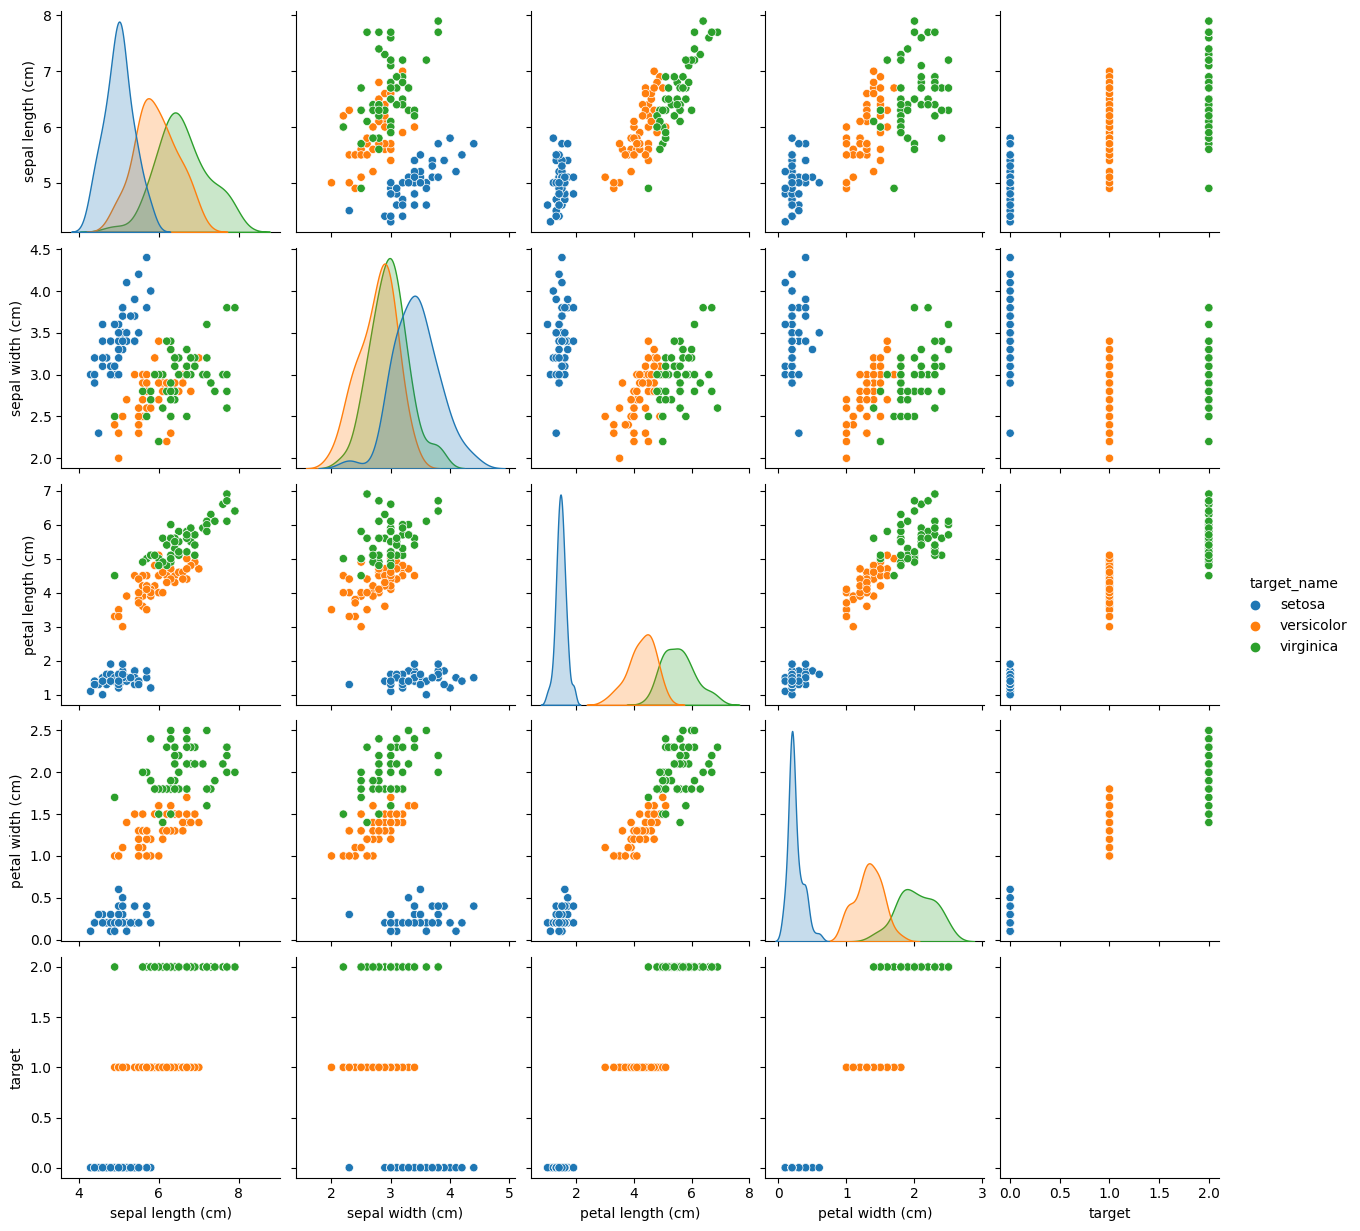

In [8]:
sns.pairplot(df, hue="target_name")

In [9]:
X = df.drop(columns=["target","target_name"])
y = df["target"]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y)
Tree_model = DecisionTreeClassifier()
Tree_model.fit(X_train,y_train)

DecisionTreeClassifier()

In [17]:
Tree_model.score(X_test,y_test)

0.9210526315789473

In [12]:
confusion_matrix(y_test, Tree_model.predict(X_test))

array([[10,  0,  0],
       [ 0, 10,  3],
       [ 0,  1, 14]])

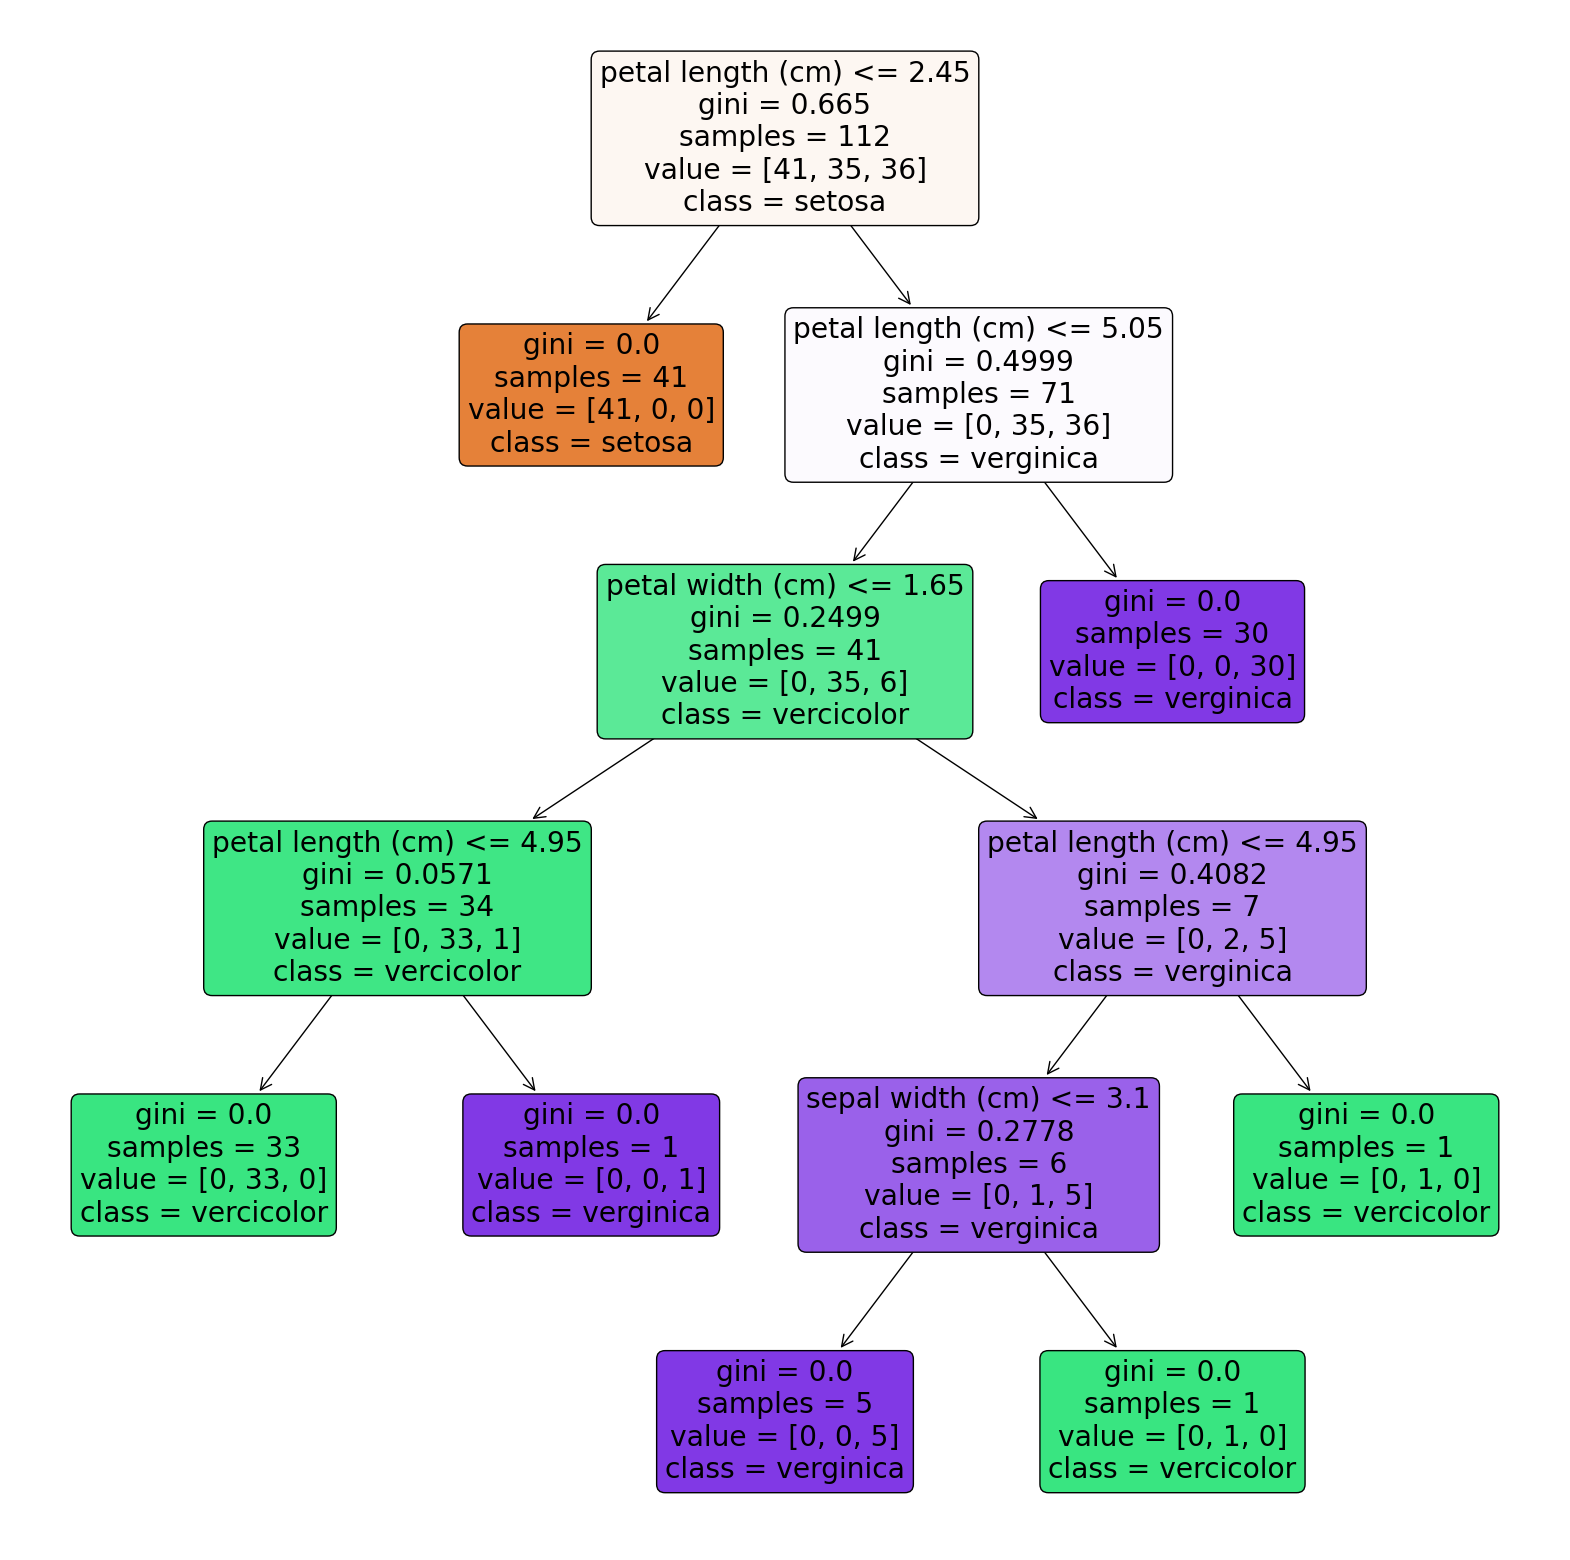

In [18]:
plt.figure(figsize=(20,20))
plot_tree(Tree_model,
         feature_names=X.columns,
         class_names = ["setosa", "vercicolor",'verginica'],
         filled=True,
         precision=4,
         rounded=True);

In [14]:
neibors = []
scores = []
for i in range(3,16):
    X_train,X_test,y_train,y_test = train_test_split(X,y, 
                                                     test_size=.20,
                                                    random_state=40)
    KNN_model = KNeighborsClassifier(n_neighbors=i)
    KNN_model.fit(X_train,y_train)
    neibors.append(i)
    scores.append(KNN_model.score(X_test,y_test))

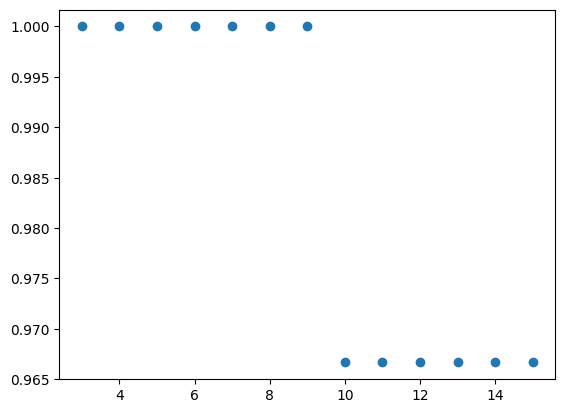

In [15]:
plt.scatter(neibors,scores)